<a href="https://colab.research.google.com/github/AndrewstheBuilder/AI_Course_Materials/blob/main/DataLabel_JiuJitsuSemanticSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Youtube Link i wanted to test: https://www.youtube.com/watch?v=HkwFwGYtqfk
#seconds to get frames from: 30-390.

In [3]:
# !pip install yt-dlp opencv-python


In [5]:
import yt_dlp

def download_video_segment(url, output_filename):
    ydl_opts = {
        'format': 'best[ext=mp4]/best',
        'outtmpl': output_filename,
        'quiet': True,
        # 'external_downloader_args': [
        #     '-ss', str(start_time),
        #     '-to', str(end_time)
        # ]
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

# Example usage
youtube_link = "https://www.youtube.com/watch?v=HkwFwGYtqfk"
# start_time = 30  # Start time in seconds
# end_time = 390   # End time in seconds
output_video = 'video_segment.mp4'

download_video_segment(youtube_link, output_video)


In [ ]:
import cv2
import os

def extract_and_save_frames(video_file, output_folder, interval=30):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    cap = cv2.VideoCapture(video_file)
    frame_rate = cap.get(cv2.CAP_PROP_FPS)  # Get frames per second
    # print('frame_rate',frame_rate)
    frame_rate = round(frame_rate)
    # print('frame rate after rounding:',frame_rate)
    frame_count = 0
    success = True

    while success:
        success, frame = cap.read()
        # print('success:',success)
        # print('frame:',frame)
        # print('frame_rate * interval',frame_rate * interval)
        # print('frame_count',frame_count)
        # print('frame_count % (frame_rate * interval)',frame_count % (frame_rate * interval))
        if not success:
            break
        # Save only every N-th frame (based on interval)
        # print('frame_count',frame_count)
        if frame_count % (frame_rate * interval) == 0:
            frame_filename = os.path.join(output_folder, f"frame_{frame_count:04d}.jpg")
            cv2.imwrite(frame_filename, frame)
        frame_count += 1

    cap.release()
    print(f"Extracted frames to {output_folder}")

# Example usage: Extract 1 frame every 1 second
output_folder = "/content/video_frames"
extract_and_save_frames(output_video, output_folder, interval=3)


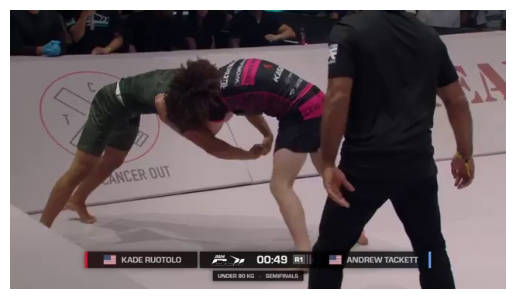

Displaying frame 38/522: /content/video_frames/frame_10260.jpg


Label saved for frame /content/video_frames/frame_10260.jpg: standing
All labels saved to frame_labels.csv


In [20]:
import os
import cv2
import ipywidgets as widgets
from IPython.display import display, clear_output
import csv
import matplotlib.pyplot as plt

# Initialize variables
output_folder = "/content/video_frames"
labels_file = "frame_labels.csv"  # To save the labels
frame_list = sorted([os.path.join(output_folder, f) for f in os.listdir(output_folder) if f.endswith('.jpg')])
current_index = 0
labels = {}

# Create widgets
label_dropdown = widgets.Dropdown(
    options=['standing', 'pinning', 'guarded', 'none'],
    value='none',
    description='Label:'
)
next_button = widgets.Button(description="Next Frame")
prev_button = widgets.Button(description="Previous Frame")
save_button = widgets.Button(description="Save Label")
save_to_csv = widgets.Button(description="Save to CSV")

# Function to display the current frame
def display_frame(index):
    clear_output(wait=True)
    frame_path = frame_list[index]
    frame = cv2.imread(frame_path)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Display frame
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

    # Show current index and label
    print(f"Displaying frame {index+1}/{len(frame_list)}: {frame_path}")
    display(widgets.HBox([prev_button, next_button, label_dropdown, save_button, save_to_csv]))

# Function to save the current label
def save_label(b):
    global current_index
    labels[frame_list[current_index]] = label_dropdown.value
    print(f"Label saved for frame {frame_list[current_index]}: {label_dropdown.value}")

# Function to go to the next frame
def next_frame(b):
    global current_index
    if current_index < len(frame_list) - 1:
        current_index += 1
        display_frame(current_index)

# Function to go to the previous frame
def prev_frame(b):
    global current_index
    if current_index > 0:
        current_index -= 1
        display_frame(current_index)

# Initial display
display_frame(current_index)

# Function to save all labels to a CSV file
def save_labels_to_csv(b=None):
    with open(labels_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Frame", "Label"])
        for frame, label in labels.items():
            writer.writerow([frame, label])
    print(f"All labels saved to {labels_file}")

# Optionally save all labels to CSV when done
save_labels_to_csv()

# Attach button events
next_button.on_click(next_frame)
prev_button.on_click(prev_frame)
save_button.on_click(save_label)
save_to_csv.on_click(save_labels_to_csv)
